<center><span style="font-size:40px;"><b>NUTS vs HMC on GERMAN CREDIT CARD POSTERIOR</b></span></center>

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt   # backend symbolic math (used inside PyMC models)

import matplotlib.pyplot as plt
import time

from ucimlrepo import fetch_ucirepo # to load datasets from the UCI ML Repository

import xarray as xr  # Imported to handle multi-dimensional tracking safely

# Set random seed for reproducibility
rng = np.random.default_rng(12345)

/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
#!pip3 install -U ucimlrepo 

---

---

---

# THE CONTEXT

We are working with the Statlog (German Credit Data) dataset, which is a classic classification problem. Each row represents a customer, described by a set of attributes, and the goal is to decide whether that customer is a good or bad credit risk.

The dataset contains 1000 individuals and 20 features. These features are a mix of numerical variables (such as age, credit amount, duration) and categorical variables (encoded as symbols like A11, A34, etc.). The categorical variables represent things like employment status, credit history, housing situation, and so on.

The target variable $y$ is the credit class:
- $y = 1$ means good credit
- $y = 2$ means bad credit

So overall, we are dealing with a supervised binary classification problem, but we will approach it from a Bayesian perspective.

The matrix $X$ contains all the input features. As said, each row is a customer, and each column is an attribute. Many of these attributes are categorical and currently represented as symbolic codes (e.g. A11, A43). These are not directly usable in a regression model, so they will need preprocessing.

The vector $y$ contains the labels. Right now it takes values in $\{1, 2\}$ (but for modeling we will convert it into $\{-1, +1\}$).

Our goal is Bayesian inference. We want to reproduce (and study) a Bayesian logistic regression model, and then compare two sampling algorithms: HMC and NUTS.

Conceptually, we assume that the probability of a customer being "good" (this is the likelihood) depends on a linear combination of the features:
$$
p(y_i = 1 \mid x_i, \alpha, \beta) = \sigma(\alpha + x_i \cdot \beta)
$$
where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the logistic function.

From a Bayesian perspective, we place priors on the parameters:
$$
\alpha \sim \mathcal{N}(0, \sigma^2), \quad \beta_j \sim \mathcal{N}(0, \sigma^2)
$$
with $\sigma^2 = 100$, a very wide (and so weak) prior.

Given the data, we infer their posterior distribution:
$$
p(\alpha, \beta \mid X, y) \propto p(y|X, \alpha, \beta) \, p(\alpha) \, p(\beta)
$$

This is the posterior we will sample from using pyMC.

But before defining the model, we need to preprocess the data properly:
* Categorical variables must be converted into numerical form. This is typically done via one-hot encoding, turning each category into binary indicator variables.
* Numerical features should be normalized so that they have comparable scale (zero mean, unit variance). This is important for HMC and NUTS, since their efficiency depends strongly on the geometry of the posterior.
* The target variable $y$ should be transformed into a consistent format (for example $\{-1,1\}$ for Bernoulli likelihood).

Once preprocessing is done, we will:
- define the Bayesian logistic regression model in PyMC
- sample from the posterior using:
  - Hamiltonian Monte Carlo (HMC)
  - No-U-Turn Sampler (NUTS)
- compare their performance using diagnostics such as:
  - effective sample size (ESS)
  - autocorrelation
  - convergence (R-hat)
  - computational cost

The main goal is to understand how HMC and NUTS behave on a real, moderately complex posterior, not anymore just a synthetic Gaussian example.

---

---

---

# DATA UPLOAD (NUMERICAL VERSION)

This is the version with all numerical columns, and  also the one used in the No U Turn paper.

In [3]:
# URL to the numeric file o the UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric"

# Il file non ha header e usa spazi bianchi come separatore
df = pd.read_csv(url, sep='\s+', header=None)

# The last column is the target (1 = Good, 2 = Bad)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_25562/3352265122.py:5: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, sep='\s+', header=None)


In [4]:
X

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,6,4,12,5,5,3,4,1,67,...,1,0,0,1,0,0,1,0,0,1
1,2,48,2,60,1,3,2,2,1,22,...,1,0,0,1,0,0,1,0,0,1
2,4,12,4,21,1,4,3,3,1,49,...,1,0,0,1,0,0,1,0,1,0
3,1,42,2,79,1,4,3,4,2,45,...,1,0,0,0,0,0,0,0,0,1
4,1,24,3,49,1,3,3,4,4,53,...,1,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4,12,2,17,1,4,2,4,1,31,...,1,0,0,1,0,0,1,0,1,0
996,1,30,2,39,1,3,1,4,2,40,...,1,0,1,1,0,0,1,0,0,0
997,4,12,2,8,1,5,3,4,3,38,...,1,0,0,1,0,0,1,0,0,1
998,1,45,2,18,1,3,3,4,4,23,...,1,0,0,1,0,0,0,0,0,1


In [5]:
y

0      1
1      2
2      1
3      1
4      2
      ..
995    1
996    1
997    1
998    2
999    1
Name: 24, Length: 1000, dtype: int64

### NORMALIZATION

In [6]:
# Normalization: zero mean and unit variance
X = (X - X.mean())/X.std()
display(X)

# Target change from {1,2} to {-1, +1}
y = 2*y - 3
display(y)

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,-1.253938,-1.235859,1.343342,-0.733065,1.832252,1.337409,0.449102,1.046463,-1.293076,2.765073,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
1,-0.458797,2.247070,-0.503176,0.965893,-0.699357,-0.317800,-0.963168,-0.765594,-1.293076,-1.190808,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
2,1.131486,-0.738298,1.343342,-0.414510,-0.699357,0.509805,0.449102,0.140434,-1.293076,1.182721,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,1.99900,-1.304224
3,-1.253938,1.749509,-0.503176,1.638398,-0.699357,0.509805,0.449102,1.046463,-0.340885,0.831087,...,-0.195916,-0.552429,-0.338692,-3.121368,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973
4,-1.253938,0.256825,0.420083,0.576549,-0.699357,-0.317800,0.449102,1.046463,1.563498,1.534354,...,-0.195916,1.808378,-0.338692,0.320052,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.131486,-0.738298,-0.503176,-0.556090,-0.699357,0.509805,-0.963168,1.046463,-1.293076,-0.399632,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,1.99900,-1.304224
996,-1.253938,0.754386,-0.503176,0.222599,-0.699357,-0.317800,-2.375438,1.046463,-0.340885,0.391544,...,-0.195916,-0.552429,2.949581,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,-1.304224
997,1.131486,-0.738298,-0.503176,-0.874645,-0.699357,1.337409,0.449102,1.046463,0.611307,0.215727,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,0.634131,-0.149908,-0.49975,0.765973
998,-1.253938,1.998289,-0.503176,-0.520695,-0.699357,-0.317800,0.449102,1.046463,1.563498,-1.102900,...,-0.195916,-0.552429,-0.338692,0.320052,-0.206664,-0.4667,-1.575384,-0.149908,-0.49975,0.765973


0     -1
1      1
2     -1
3     -1
4      1
      ..
995   -1
996   -1
997   -1
998    1
999   -1
Name: 24, Length: 1000, dtype: int64

---

---

# MODEL TEST

The target distribution is $p(\alpha, \beta \mid X, y) \propto p(y|X, \alpha, \beta) \, p(\alpha) \, p(\beta)$, so:

$$
p(\alpha, \beta \mid X, y) \propto
\exp\left(
-\sum_{i}\log\!\left(1+\exp\!\left\{-y_i\left(\alpha + x_i \cdot \beta\right)\right\}\right)
-\frac{\alpha^2}{2\sigma^2}
-\frac{1}{2\sigma^2}\,\beta \cdot \beta
\right)
$$



In [7]:
# "α and each element of β are given weak zero-mean normal priors with variance σ^2 = 100"
prior_mean = 0
prior_var = 100

TARGET_ACCEPT = 0.9
CHAINS = 4

---

# ACCEPTANCE RATE ANALYSIS

NUTS internally tune the step size so that the average acceptance probability is close to a target value 
$\delta=\textit{TARGET\_ACCEPT}$

We now check if the sampler actually reached this target and how much uncertainty do we have on that estimate.

When we run HMC or NUTS, to obtain the mean acceptance rate we could compute:
$$
\mu_a = \frac{1}{N} \sum_{i=1}^N a_i
$$
where $a_i$ is the acceptance probability at iteration $i$.

But our samples are *correlated*, so $\mu_a$ is not as precise as it would be with independent samples. We want to know how much uncertainty is there in this estimate. That is the **Monte Carlo Standard Error (MCSE)**.

Instead of treating all samples as independent (wrong), we split the chain into *batches*, compute the *mean inside each batch* and treat those batch means as approximately independent. Then compute the variance across batches.

In [9]:
# Monte Carlo Standard Error (MCSE) on realized mean acceptance rate
def mcse_batch_means(x, batch_size=None, min_batches=20):
    """
    We split the sinle input chain into m batches
    Compute the mean of each batch
    Treats those batch means as approximately independent
    Estimates variance from them
    """
    x = np.asarray(x, dtype=float).ravel()   # now this is a 1D array
    n = x.size                               # number of samples
    
    if batch_size is None:
        batch_size = int(np.sqrt(n))
    batch_size = max(1, int(batch_size))
    m = n // batch_size                      # m = number of batches
    
    if m < min_batches:   
        batch_size = max(1, n // min_batches) # ensures at least min_batches (default 20)
        m = n // batch_size
        
    if m < 2:  # safety check
        raise ValueError(f"Not enough data: n={n}, batch_size={batch_size}, batches={m}")

    # discards leftover samples so reshape works cleanly
    n_used = m * batch_size
    x_used = x[:n_used]
    
    # BATCH MEANS:
    batch_means = x_used.reshape(m, batch_size).mean(axis=1)   # we obtain m means
    mcse = batch_means.std(ddof=1) / np.sqrt(m)                # computes mcse with independent approx
    
    return mcse

---

# TARGET ACCEPTANCE RATE ANALYSIS

We want to study how the **target acceptance rate** affects the efficiency of NUTS.

In HMC/NUTS, there is a key tradeoff:
* *low acceptance rate* → large step size → cheap trajectories but inaccurate
* *high acceptance rate* → small step size → accurate but expensive

So the question is: what value of target acceptance gives the best efficiency?

During tuning, $\epsilon$ is adapted so that $\mathbb{E}[\text{acceptance rate}] \approx \delta$ where $\delta$ = `target_accept`. So by varying `target_accept`, you are indirectly changing $ \epsilon \Rightarrow \text{trajectory length, accuracy, cost} $.

### APPROACH

We are looping over many $\delta$ values: $ \delta \in [0.20, 0.98]$.

For each value:

1. run NUTS
2. measure what actually happens
3. evaluate efficiency

So we compute:
1. Acceptance rate:
$$
h_c = \frac{1}{T} \sum_t a_{c,t}
\quad \text{and} \quad
h_c - \delta
$$

2. *Effective Sample Size (ESS)*, which measures statistical efficiency for $\alpha$ (scalar) plus $\beta$ (vector, 24 dims):
$$
\text{ESS} \approx \frac{N}{1 + 2\sum_k \rho_k}
$$
But ESS alone is not enough. Different runs have different computational costs. In HMC/NUTS $\text{cost} \propto \text{\# gradient evaluations}$, where each leapfrog step = 1 gradient evaluation.\
So the key metric is **ESS per gradient evaluation (unit of computation)**, and we compute:
$$
\frac{\text{ESS}}{\text{\# gradient evaluations}}
$$
This is the right metric because:
    * small $\epsilon$ (high acceptance) $\Rightarrow $ high ESS (good mixing) but many steps → expensive
    * large $\epsilon$ (low acceptance) $\Rightarrow $ cheap steps but poor mixing → low ESS

    So the tradeoff is $\text{efficiency} = \frac{\text{ESS}}{\text{cost}}$


Then:
* average (or take minimum, more conservative) over chains
* average (or take minimum, more conservative) over parameters
to get a single scalar efficiency measure for each $\delta$ value.

---

### RESULTS

We will end up with:
* x-axis: target acceptance $\delta$
* y-axis: efficiency (ESS per gradient)

And we want to see where is the maximum. From theory (and the NUTS paper) optimal $\delta$ is typically around $ 0.6 \text{ to } 0.9 $. We should see a peak in efficiency.

In [15]:
# In function of the target acceptance:
prior_mean = 0                              # Mean of the Gaussian prior for parameters
prior_var = 100                             # Variance of the Gaussian prior

CHAINS = 4                                  # Number of MCMC chains to run in parallel
N_EXPERIMENTS = 10                          # NEW: number of repeated experiments (different seeds)

accept_rate_list = np.arange(0.20, 0.99, 0.02)  # Range of target acceptance rates to explore

# NEW: add experiment dimension → (experiment, delta, chain)
all_diffs = np.zeros(shape=(N_EXPERIMENTS, len(accept_rate_list), CHAINS))  
all_mcse  = np.zeros_like(all_diffs)        

# NEW: store ESS results per experiment
ESS_GRAD_EV_ALPHA = []    # will become list of length N_EXPERIMENTS
ESS_GRAD_EV_BETA = []     
ESS_GRAD_EV_SCALAR = []   

# Choose the ESS metric method:
metric_choice = "paper"                     # "paper" (mean vs second central moment) or "modern" (bulk vs tail)

# Choose how to aggregate across dimensions at the very end:
aggregation_choice = "min"                  # "min" (strict paper methodology) or "mean" (average across dimensions)


In [16]:
# ======================= MODEL DEFINITION =================
# We define the model logic inside a function so we can reuse it for both baseline and experiment runs
def create_model(X, y):
    with pm.Model() as model:  
        X_data = pm.Data("X", X)  # Register feature matrix X as shared data inside the model
        y_data = pm.Data("y", y) 
        
        # Priors
        alpha = pm.Normal("alpha", mu=0.0, sigma=np.sqrt(prior_var))  
        beta  = pm.Normal("beta", mu=0.0, sigma=np.sqrt(prior_var), shape=X_data.shape[1]) 

        # eta_i = alpha + x_i * beta
        eta = alpha + pt.dot(X_data, beta)  # Linear predictor

        # log-likelihood: -sum_i log(1 + exp(-y_i * eta_i))
        loglike = -pt.sum(pt.log1p(pt.exp(-y_data * eta)))  

        pm.Potential("likelihood", loglike)  # Add custom log-likelihood term to the model
    return model

In [17]:
# =========================== MODEL CREATION ======================
my_model = create_model(X, y)

In [18]:
# ======================= BASELINE RUN (50k Samples) =================
if metric_choice == "paper":
    print("Running baseline 50,000 samples to compute mu_true for the second central moment...")
    with my_model:
        baseline_idata = pm.sample(
            draws=50000, 
            tune=1000, 
            chains=1,                       # The paper runs a single long chain for the baseline
            target_accept=0.5,              # delta = 0.5 as specified in the paper
            random_seed=42,
            nuts_sampler="pymc",
            progressbar=True
        )
    # Extract the highly precise true means (mu_true)
    mu_true_alpha = baseline_idata.posterior["alpha"].mean().values
    mu_true_beta = baseline_idata.posterior["beta"].mean(dim=["chain", "draw"]).values
    print("Baseline complete. mu_true calculated.")

Initializing NUTS using jitter+adapt_diag...


Running baseline 50,000 samples to compute mu_true for the second central moment...


Sequential sampling (1 chains in 1 job)
NUTS: [alpha, beta]


Output()

Sampling 1 chain for 1_000 tune and 50_000 draw iterations (1_000 + 50_000 draws total) took 27 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


Baseline complete. mu_true calculated.


In [19]:
# ======================= MAIN EXPERIMENT =================
with my_model:
    print(f"Iteration progress:")

    # ===== NEW: LOOP over experiments =====
    for exp in range(N_EXPERIMENTS):

        print(f"\nExperiment {exp+1}/{N_EXPERIMENTS}")

        # temporary containers for this experiment
        ESS_GRAD_EV_ALPHA_exp = []
        ESS_GRAD_EV_BETA_exp = []
        ESS_GRAD_EV_SCALAR_exp = []

        # ===== LOOP over target acceptance =====
        for i, target_accept in enumerate(accept_rate_list): 
        
            print(f"{i+1}/{len(accept_rate_list)}", end="  ")   # debug progress
        
            idata = pm.sample(  
                draws=1000,     # number of posterior samples (after warmup)
                tune=1000,      # number of warmup steps
                chains=CHAINS, 
                target_accept=target_accept,
                random_seed=2026 + exp,       # different seed per experiment
                progressbar = False,          # disable progress bar
                quiet = True,                 # suppress sampler messages
                nuts_sampler = "pymc",        # use PyMC's NUTS implementation
            )
        
            acceptance = idata.sample_stats["acceptance_rate"].to_numpy()  # extract acceptance rates (chains, draws)
            h_chain = acceptance.mean(axis=1)     # mean acceptance per chain
            diff_chain = h_chain - target_accept  # deviation from target δ per chain
            mcse = np.zeros(CHAINS)

            # =========== LOOP over chains (Only for MCSE/Acceptance stats) ===============
            for c in range(CHAINS): 
                mcse[c] = mcse_batch_means(acceptance[c])
            # ================= end loop =================

            # NEW: store with experiment index
            all_diffs[exp, i] = diff_chain    # store chains deviations for this δ
            all_mcse[exp, i]  = mcse          # store chains MCSE values for this δ

            
            # ============== Computing ESS and Gradient Evaluations =============
        
            # Get the number of steps (POST WARM UP) 
            n_steps = idata.sample_stats["n_steps"].to_numpy()         # shape: (chains, draws)

            # ESS is normalized by the TOTAL amount of gradient evaluations across all samples
            # Total gradient evaluations across all chains and draws
            total_grad_evals = n_steps.sum()  
            
            # Calculate Multi-chain ESS based on user choice
            if metric_choice == "paper":
                # 1. Compute Mean ESS
                ess_mean = az.ess(idata, method="mean")

                # 2. Compute Second Central Moment ESS
                # FIX: Keep data as an xarray Dataset so ArviZ preserves named dimensions for the 24D beta
                sq_diff_ds = xr.Dataset({
                    "alpha": (idata.posterior["alpha"] - mu_true_alpha)**2,
                    "beta": (idata.posterior["beta"] - mu_true_beta)**2
                })
                ess_var = az.ess(sq_diff_ds, method="mean")

                # 3. Take the minimum between mean and variance for each dimension
                # Both ess_mean and ess_var are now clean xarray Datasets, so .values extracts the array properly
                ess_alpha = np.minimum(ess_mean["alpha"].values, ess_var["alpha"].values)
                ess_beta = np.minimum(ess_mean["beta"].values, ess_var["beta"].values)
                
            elif metric_choice == "modern":
                # 1. Compute Bulk and Tail ESS natively
                ess_bulk = az.ess(idata, method="bulk")
                ess_tail = az.ess(idata, method="tail")

                # 2. Take the minimum between bulk and tail for each dimension
                ess_alpha = np.minimum(ess_bulk["alpha"].values, ess_tail["alpha"].values)
                ess_beta = np.minimum(ess_bulk["beta"].values, ess_tail["beta"].values)

            
            # Normalize by total gradient evaluations
            # Results are now a scalar (for alpha) and an array of 24 (for beta), evaluated ACROSS all chains
            ess_per_grad_alpha = ess_alpha / total_grad_evals  
            ess_per_grad_beta = ess_beta / total_grad_evals 

            # Final Aggregation across dimensions to get a single number
            if aggregation_choice == "mean":
                # Average across dimensions
                mean_ess_grad_beta = np.mean(ess_per_grad_beta)
                ESS_PER_GRAD = np.mean([ess_per_grad_alpha, mean_ess_grad_beta]) 

            elif aggregation_choice == "min":
                # Strict paper methodology: take the absolute worst-case dimension
                all_ess_per_grad = np.append(ess_per_grad_alpha, ess_per_grad_beta)
                ESS_PER_GRAD = np.min(all_ess_per_grad)

            
            # Store results for THIS experiment
            ESS_GRAD_EV_ALPHA_exp.append(ess_per_grad_alpha)  
            ESS_GRAD_EV_BETA_exp.append(ess_per_grad_beta)  
            ESS_GRAD_EV_SCALAR_exp.append(ESS_PER_GRAD)

        # ===== END loop over delta =====

        # Append experiment results to global lists
        ESS_GRAD_EV_ALPHA.append(ESS_GRAD_EV_ALPHA_exp)
        ESS_GRAD_EV_BETA.append(ESS_GRAD_EV_BETA_exp)
        ESS_GRAD_EV_SCALAR.append(ESS_GRAD_EV_SCALAR_exp)

Iteration progress:
Experiment 1/10
1/40  2/40  3/40  4/40  5/40  6/40  7/40  8/40  9/40  10/40  11/40  12/40  13/40  14/40  15/40  16/40  17/40  18/40  19/40  20/40  21/40  22/40  23/40  24/40  25/40  26/40  27/40  28/40  29/40  30/40  31/40  32/40  33/40  34/40  35/40  36/40  37/40  38/40  39/40  40/40  Experiment 2/10
1/40  2/40  3/40  4/40  5/40  6/40  7/40  8/40  9/40  10/40  11/40  12/40  13/40  14/40  15/40  16/40  17/40  18/40  19/40  20/40  21/40  22/40  23/40  24/40  25/40  26/40  27/40  28/40  29/40  30/40  31/40  32/40  33/40  34/40  35/40  36/40  37/40  38/40  39/40  40/40  Experiment 3/10
1/40  2/40  3/40  4/40  5/40  6/40  7/40  8/40  9/40  10/40  11/40  12/40  13/40  14/40  15/40  16/40  17/40  18/40  19/40  20/40  21/40  22/40  23/40  24/40  25/40  26/40  27/40  28/40  29/40  30/40  31/40  32/40  33/40  34/40  35/40  36/40  37/40  38/40  39/40  40/40  Experiment 4/10
1/40  2/40  3/40  4/40  5/40  6/40  7/40  8/40  9/40  10/40  11/40  12/40  13/40  14/40  15/40  16/40  

### RESULTS VISUALIZATION

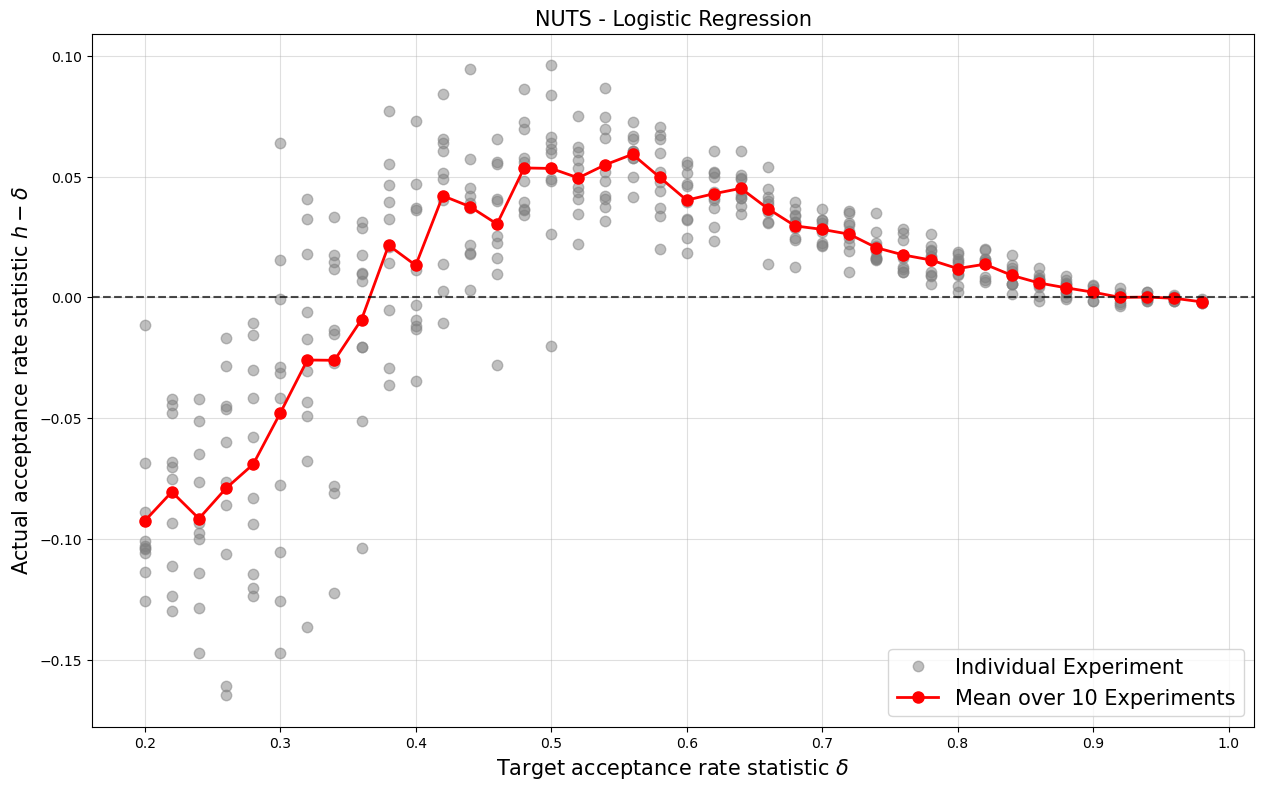

In [26]:
# 1. Collapse the 4 chains into 1 value per experiment per delta
# Shape changes from: (N_EXPERIMENTS, len(accept_rate_list), CHAINS) -> (N_EXPERIMENTS, len(accept_rate_list))
exp_diffs = all_diffs.mean(axis=2)

# 2. Compute the mean profile over all 10 experiments
# Shape changes from: (N_EXPERIMENTS, len(accept_rate_list)) -> (len(accept_rate_list),)
mean_across_experiments = exp_diffs.mean(axis=0)

# Setup the plot
fig, ax = plt.subplots(figsize=(15, 9))

# 3. Plot each individual experiment in gray
# We loop over the 10 experiments and map them against accept_rate_list
for exp in range(N_EXPERIMENTS):
    # 'alpha=0.5' makes overlapping lines look beautifully semi-transparent
    # We only attach a label to the first iteration so the legend doesn't show "Individual Experiment" 10 times
    label = "Individual Experiment" if exp == 0 else ""
    ax.plot(accept_rate_list, exp_diffs[exp], color="gray", alpha=0.5, ls="None", marker=".", ms=15, label=label)

# 4. Plot the red dots/line representing the mean across all 10 experiments
ax.plot(accept_rate_list, mean_across_experiments, color="red", ls="-", marker="o", ms=8, lw=2, label="Mean over 10 Experiments")

# Formatting matching the style of the NUTS paper
plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
plt.ylabel(r"Actual acceptance rate statistic $h - \delta$", fontsize=15)
plt.title("NUTS - Logistic Regression", fontsize=15)
plt.legend(loc="lower right", fontsize=15)
plt.axhline(y=0.0, ls="--", color="black", alpha=0.7)  # Clear zero reference line
plt.grid(alpha=0.4)
plt.show()

# ESS

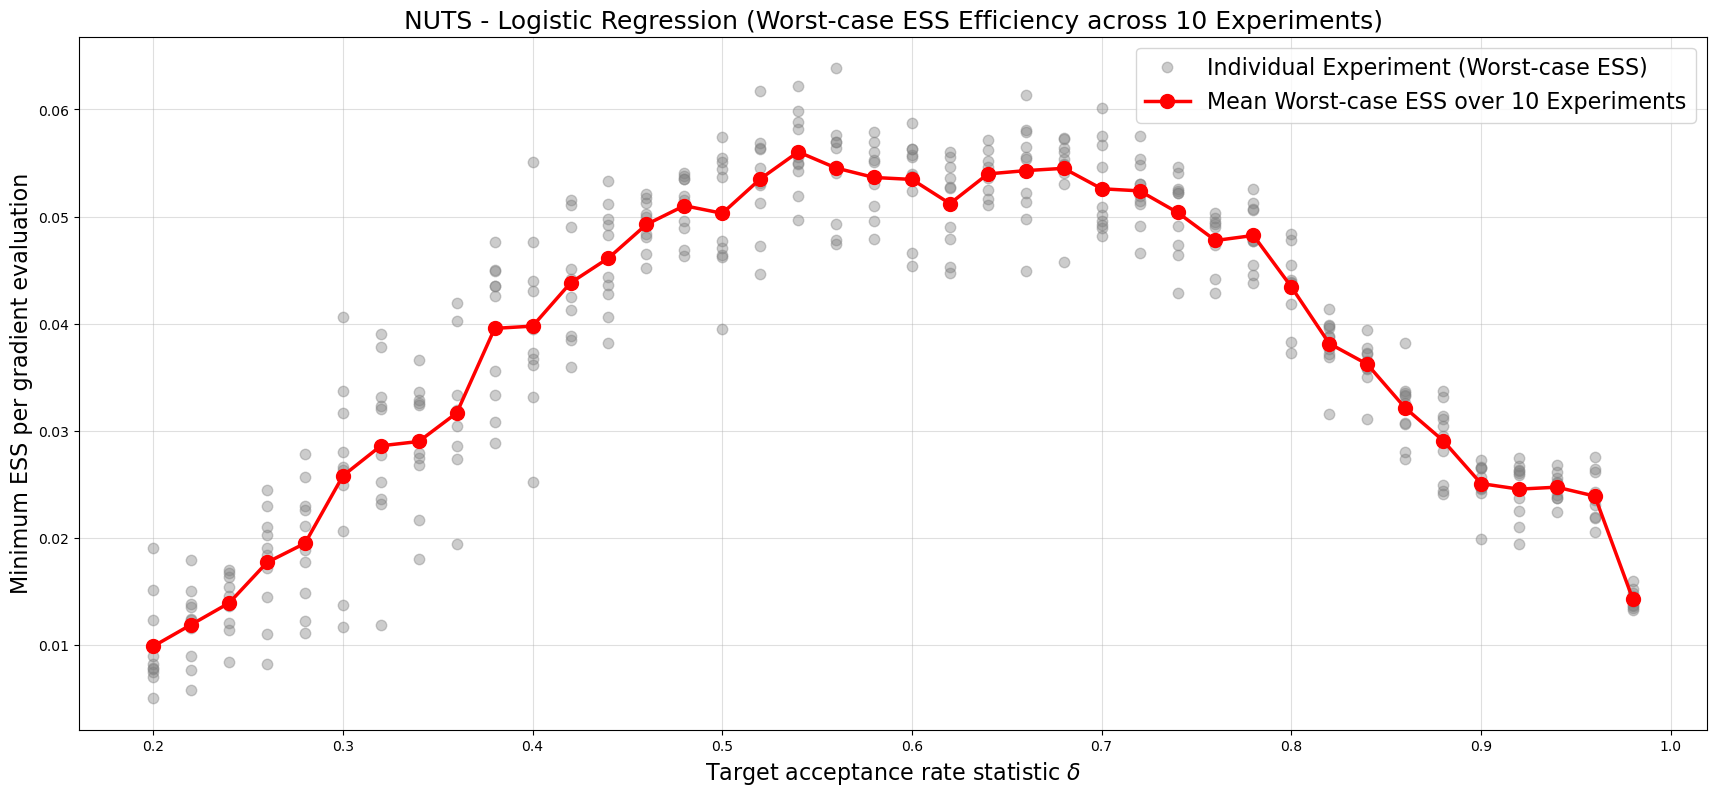

In [31]:
# 1. Convert the nested global list of scalars into a 2D NumPy array
# Shape will be: (N_EXPERIMENTS, len(accept_rate_list)) -> (10, len(accept_rate_list))
exp_ess_scalar = np.array(ESS_GRAD_EV_SCALAR)

# 2. Compute the mean minimum ESS profile over all 10 experiments
# Shape drops to: (len(accept_rate_list),)
mean_ess_across_experiments = exp_ess_scalar.mean(axis=0)

# Setup the plot layout (21x9 as in your original script)
fig, ax = plt.subplots(figsize=(21, 9))

# 3. Plot each individual experiment's minimum ESS path in gray
for exp in range(N_EXPERIMENTS):
    # Only label the first line to keep the legend clean
    label = "Individual Experiment (Worst-case ESS)" if exp == 0 else ""
    ax.plot(
        accept_rate_list, 
        exp_ess_scalar[exp], 
        color="gray", 
        alpha=0.4, 
        ls="None", 
        marker=".", 
        ms=15, 
        label=label
    )

# 4. Plot the red dots/line representing the average path across all 10 experiments
ax.plot(
    accept_rate_list, 
    mean_ess_across_experiments, 
    color="red", 
    ls="-", 
    marker="o", 
    ms=10, 
    lw=2.5, 
    label="Mean Worst-case ESS over 10 Experiments"
)

# Labelling and formatting
plt.xlabel(r"Target acceptance rate statistic $\delta$", fontsize=16)
plt.ylabel("Minimum ESS per gradient evaluation", fontsize=16)
plt.title("NUTS - Logistic Regression (Worst-case ESS Efficiency across 10 Experiments)", fontsize=18)
plt.legend(loc="upper right", fontsize=16)
plt.grid(alpha=0.4)
plt.show()